In [20]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2023-09-01"
# end_date: str = "2025-10-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [21]:
from pathlib import Path
import copy
import pandas as pd

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if len(df) ==1140480:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


btc = coins_dict["BTCUSDT"]
# chosen = [ 
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT"
#     ]
chosen = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
    "LINKUSDT", "TRXUSDT",
      "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
    "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
    "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
    "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
    "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
    "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
]

HEDGE_LIST = {k: v for k, v in coins_dict.items() if k in chosen}


temp = copy.copy(HEDGE_LIST)

Processing symbol: IMXUSDT, length: 1140480
Processing symbol: SOLUSDT, length: 1140480
Processing symbol: LTCUSDT, length: 1140480
Processing symbol: SUIUSDT, length: 1140480
Processing symbol: NEARUSDT, length: 1140480
Processing symbol: ATOMUSDT, length: 1140480
Processing symbol: APTUSDT, length: 1140480
Processing symbol: GALAUSDT, length: 1140480
Processing symbol: ARBUSDT, length: 1140480
Processing symbol: TRXUSDT, length: 1140480
Processing symbol: BNBUSDT, length: 1140480
Processing symbol: DOTUSDT, length: 1140480
Processing symbol: FILUSDT, length: 1140480
Processing symbol: ETCUSDT, length: 1140480
Processing symbol: FLOKIUSDT, length: 1140480
Processing symbol: BTCUSDT, length: 1140480
Processing symbol: LINKUSDT, length: 1140480
Processing symbol: SHIBUSDT, length: 1140480
Processing symbol: SEIUSDT, length: 1140480
Processing symbol: MOVRUSDT, length: 1140480
Processing symbol: XRPUSDT, length: 1140480
Processing symbol: PEPEUSDT, length: 1140480
Processing symbol: ADAU

In [22]:
HEDGE_LIST = temp

In [23]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os
from datetime import datetime


In [24]:
len(HEDGE_LIST.keys())

34

In [25]:
# def record_stats_to_txt(time_idx, xy_1_sum, xx_1_sum, yy_1_sum, x_1_sum, y_1_sum,
#                        xy_2_sum, xx_2_sum, yy_2_sum, x_2_sum, y_2_sum,
#                        xy_3_sum, xx_3_sum, yy_3_sum, x_3_sum, y_3_sum,
#                        output_file="stats_record.txt"):
#     """
#     Record statistical sums to a text file
    
#     Args:
#         time_idx: Current time index
#         *_sum: Various statistical sum dictionaries
#         output_file: Output file path
#     """
    
#     # Create output directory if it doesn't exist
#     os.makedirs(os.path.dirname(output_file) if os.path.dirname(output_file) else '.', exist_ok=True)
    
#     # Get current timestamp
#     timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
#     # Write to file
#     with open(output_file, 'a', encoding='utf-8') as f:
#         f.write(f"\n{'='*80}\n")
#         f.write(f"Time Index: {time_idx} | Timestamp: {timestamp}\n")
#         f.write(f"{'='*80}\n")
        
#         # Write data for each symbol
#         for name in xy_1_sum.keys():
#             f.write(f"\nSymbol: {name}\n")
#             f.write(f"  xy_1_sum: {xy_1_sum[name]:.6f}\n")
#             f.write(f"  xx_1_sum: {xx_1_sum[name]:.6f}\n")
#             f.write(f"  yy_1_sum: {yy_1_sum[name]:.6f}\n")
#             f.write(f"  x_1_sum:  {x_1_sum[name]:.6f}\n")
#             f.write(f"  y_1_sum:  {y_1_sum[name]:.6f}\n")
#             f.write(f"  xy_2_sum: {xy_2_sum[name]:.6f}\n")
#             f.write(f"  xx_2_sum: {xx_2_sum[name]:.6f}\n")
#             f.write(f"  yy_2_sum: {yy_2_sum[name]:.6f}\n")
#             f.write(f"  x_2_sum:  {x_2_sum[name]:.6f}\n")
#             f.write(f"  y_2_sum:  {y_2_sum[name]:.6f}\n")
#             f.write(f"  xy_3_sum: {xy_3_sum[name]:.6f}\n")
#             f.write(f"  xx_3_sum: {xx_3_sum[name]:.6f}\n")
#             f.write(f"  yy_3_sum: {yy_3_sum[name]:.6f}\n")
#             f.write(f"  x_3_sum:  {x_3_sum[name]:.6f}\n")
#             f.write(f"  y_3_sum:  {y_3_sum[name]:.6f}\n")

In [ ]:

BULLET_SIZE = 1000
INITIAL = 100000127




FORWARD_WINDOW = 600
BACK_WINDOW = 600
# FORWARD_WINDOW = 150
# BACK_WINDOW = 300





In [31]:


i=1
# for name, df in HEDGE_LIST.items():
#     HEDGE_LIST[name] = df.iloc[:200000]    
    
# btc = btc.iloc[:200000]    

# start_t = 0*half_length
start_t=0


back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


btc_close = deque(btc['Close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

btc_volume = deque(btc['Volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['Volume'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

mkt_idx_1 = deque(np.array([0]*back_window), maxlen=back_window)
mkt_idx_2 = deque(np.array([0]*back_window), maxlen=back_window)
mkt_idx_3 = deque(np.array([0]*back_window), maxlen=back_window)

xy_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
xx_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
yy_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
x_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
y_1 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
xy_2 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
xx_2 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
yy_2 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
x_2 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
y_2 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
xy_3 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
xx_3 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
yy_3 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
x_3 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
y_3 = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}

amihud = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
amihud_avg = {name: 0 for name in HEDGE_LIST.keys()}


xy_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
xx_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
yy_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
x_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
y_1_sum = {name: 0 for name in HEDGE_LIST.keys()}
xy_2_sum = {name: 0 for name in HEDGE_LIST.keys()}
xx_2_sum = {name: 0 for name in HEDGE_LIST.keys()}
yy_2_sum = {name: 0 for name in HEDGE_LIST.keys()}
x_2_sum = {name: 0 for name in HEDGE_LIST.keys()}
y_2_sum = {name: 0 for name in HEDGE_LIST.keys()}
xy_3_sum = {name: 0 for name in HEDGE_LIST.keys()}
xx_3_sum = {name: 0 for name in HEDGE_LIST.keys()}
yy_3_sum = {name: 0 for name in HEDGE_LIST.keys()}
x_3_sum = {name: 0 for name in HEDGE_LIST.keys()}
y_3_sum = {name: 0 for name in HEDGE_LIST.keys()}


cmi_dict = {}


time_range = range(back_window, len(btc) - forward_window)

num = 0
revenues = []
coin_revenues = {name: [] for name in HEDGE_LIST.keys()}
stats_1 = []
stats_2 = []
stats_3 = []
stats_4 = []
stats_5 = []
stats_6 = []
stats_7 = []
stats_8 = []
stats_9 = []
stats_10 = []
stats_11 = []
stats_12 = []
idx = []



sum_of_theta_price = 0

print_df = None

for i, t in tqdm(enumerate(time_range), total=len(time_range), desc="Sliding window"):

 

    btc_close.append(btc['Close'].iloc[t])
    btc_volume.append(btc['Volume'].iloc[t])

    arr = np.array(btc_close)

    diff = np.diff(arr)
    cmi_btc = (arr[-1] - arr[0]) / np.sum(np.abs(diff))*100

    fz = 0
    fm = 0

    coef_records = {name: [] for name in HEDGE_LIST.keys()}

    for name, df in HEDGE_LIST.items():
        time = df['Open Time'].iloc[t]
        coin_closes[name].append(df['Close'].iloc[t])
        coin_volumes[name].append(df['Volume'].iloc[t])

        if i>=back_window:

            growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2])
            fz += growth*df['Volume'].iloc[t]
            fm += df['Volume'].iloc[t]*df['Close'].iloc[t]

    if i>=back_window:
        mkt_idx_1.append(btc['Close'].iloc[t])
        mkt_idx_2.append(btc['Close'].iloc[t-1])
        mkt_idx_3.append(fz/fm)


        mkt_idx_1_diff = mkt_idx_1[-1]-mkt_idx_1[-2]
        mkt_idx_2_diff = mkt_idx_2[-1]-mkt_idx_2[-2]
        mkt_idx_3_diff = mkt_idx_3[-1]


        for name, _ in HEDGE_LIST.items():

            diff = np.diff(np.array(coin_closes[name]))
            cmi = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[0]) / np.sum(np.abs(diff))*100

            growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 

            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

                xy_2_sum[name] -= xy_2[name][0]
                xx_2_sum[name] -= xx_2[name][0]
                yy_2_sum[name] -= yy_2[name][0]
                x_2_sum[name] -= x_2[name][0]
                y_2_sum[name] -= y_2[name][0]

                xy_3_sum[name] -= xy_3[name][0]
                xx_3_sum[name] -= xx_3[name][0]
                yy_3_sum[name] -= yy_3[name][0]
                x_3_sum[name] -= x_3[name][0]
                y_3_sum[name] -= y_3[name][0]

                amihud_avg[name] = (amihud_avg[name]*back_window - amihud[name][0])/back_window

            xy_1[name].append(growth*mkt_idx_1_diff)
            xx_1[name].append(mkt_idx_1_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_1_diff)
            y_1[name].append(growth)
            xy_2[name].append(growth*mkt_idx_2_diff)
            xx_2[name].append(mkt_idx_2_diff**2)
            yy_2[name].append(growth**2)
            x_2[name].append(mkt_idx_2_diff)
            y_2[name].append(growth)
            xy_3[name].append(growth*mkt_idx_3_diff)
            xx_3[name].append(mkt_idx_3_diff**2)
            yy_3[name].append(growth**2)
            x_3[name].append(mkt_idx_3_diff)
            y_3[name].append(growth)

            amihud[name].append(abs(growth)/(df['Volume'].iloc[t]+1e-9)/df['Close'].iloc[t]/df['Close'].iloc[t])


            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            xy_2_sum[name] += xy_2[name][-1]
            xx_2_sum[name] += xx_2[name][-1]
            yy_2_sum[name] += yy_2[name][-1]
            x_2_sum[name] += x_2[name][-1]
            y_2_sum[name] += y_2[name][-1]
            xy_3_sum[name] += xy_3[name][-1]
            xx_3_sum[name] += xx_3[name][-1]
            yy_3_sum[name] += yy_3[name][-1]
            x_3_sum[name] += x_3[name][-1]
            y_3_sum[name] += y_3[name][-1]

            amihud_avg[name] = (amihud_avg[name]*back_window + amihud[name][-1])/back_window

            if i >= 2*back_window:
                coef_1 = xy_1_sum[name]/xx_1_sum[name]*1000 if xx_1_sum[name]!=0 else 0
                coef_2 = xy_2_sum[name]/xx_2_sum[name]*1000 if xx_2_sum[name]!=0 else 0 
                coef_3 = xy_3_sum[name]/xx_3_sum[name]*1000 if xx_3_sum[name]!=0 else 0

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0
                corr_2 = (back_window * xy_2_sum[name] - x_2_sum[name]*y_2_sum[name]) / np.sqrt((back_window*xx_2_sum[name]-x_2_sum[name]**2)*(back_window*yy_2_sum[name]-y_2_sum[name]**2)) if (back_window*xx_2_sum[name]-x_2_sum[name]**2)*(back_window*yy_2_sum[name]-y_2_sum[name]**2) >0 else 0
                corr_3 = (back_window * xy_3_sum[name] - x_3_sum[name]*y_3_sum[name]) / np.sqrt((back_window*xx_3_sum[name]-x_3_sum[name]**2)*(back_window*yy_3_sum[name]-y_3_sum[name]**2)) if (back_window*xx_3_sum[name]-x_3_sum[name]**2)*(back_window*yy_3_sum[name]-y_3_sum[name]**2) >0 else 0

                # RETURN
                coef_records[name] = {
                    'coef_1': coef_1,
                    'coef_2': coef_2,   
                    'coef_3': coef_3,
                    'corr_1': corr_1,
                    'corr_2': corr_2,         
                    'corr_3': corr_3,    
                    'cmi': cmi,
                    'amihud': amihud_avg[name],
                }


        if i >= 2*back_window:

            # if (i+start_t) % forward_window == 0:
            if (i+start_t) % 1 == 0:
                # print(f"\n=== Step {i}: Coefficients collected for all coins ===")
                # === 将 coef_records 转为 DataFrame ===
                coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin

                coef_df['cmi'] = coef_df['cmi'].astype(float)
                coef_df['coef_1'] = coef_df['coef_1']
                coef_df['coef_2'] = coef_df['coef_2']
                coef_df['coef_3'] = coef_df['coef_3']
                coef_df['corr_1'] = coef_df['corr_1']
                coef_df['corr_2'] = coef_df['corr_2']
                coef_df['corr_3'] = coef_df['corr_3']

                coef_1_mean = coef_df['coef_1'].mean()
                coef_2_mean = coef_df['coef_2'].mean()
                coef_3_mean = coef_df['coef_3'].mean()
                corr_1_mean = coef_df['corr_1'].mean()
                corr_2_mean = coef_df['corr_2'].mean()
                corr_3_mean = coef_df['corr_3'].mean()
                cmi_mean = coef_df['cmi'].mean()
                cmi_std = coef_df['cmi'].std()
                amihud_mean = coef_df['amihud'].mean()

                names = coef_df.index.tolist()
                coef1 = coef_df['coef_1'].values.astype(float)
                coef2 = coef_df['coef_2'].values.astype(float)
                coef3 = coef_df['coef_3'].values.astype(float)
                prices = coef_df.index.map(lambda n: HEDGE_LIST[n]['Close'].iloc[t]).values.astype(float)


                k = len(prices)

                cmis = coef_df['cmi'].values.astype(float)


                # 原目标函数 c^T x
                c_x = -cmis *prices

                # 我们引入新的变量 y_i 表示 |x_i * prices_i|
                # 所以变量总数 = k (x_i) + k (y_i)
                c = np.concatenate([c_x, np.zeros(k)])  # 目标函数只作用在 x 上

                # 线性约束 A_eq x = b_eq
                A_eq = np.hstack([np.vstack([coef1]), np.zeros((1, k))])
                b_eq = np.zeros(1)

                # --- 绝对值约束部分 ---
                # 对于每个 i: y_i >=  prices_i * x_i
                #             y_i >= -prices_i * x_i
                #             sum(y_i) <= 1000
                A_ub = []
                b_ub = []

                for i in range(k):
                    row_pos = np.zeros(2 * k)
                    row_pos[i] = prices[i]
                    row_pos[k + i] = -1
                    A_ub.append(row_pos)
                    b_ub.append(0.0)

                    row_neg = np.zeros(2 * k)
                    row_neg[i] = -prices[i]
                    row_neg[k + i] = -1
                    A_ub.append(row_neg)
                    b_ub.append(0.0)

                # sum(y_i) <= 1000
                row_sum = np.zeros(2 * k)
                row_sum[k:] = 1.0
                A_ub.append(row_sum)
                b_ub.append(1000.0)

                A_ub = np.array(A_ub)
                b_ub = np.array(b_ub)

                # 变量边界
                bounds = [(-np.inf, np.inf)] * k + [(0, np.inf)] * k
                

                # 求解线性规划
                res = linprog(c=c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

                objective_value = res.fun  

                # if res.success and corr_2_mean>0.1 and corr_1_mean>0.6 and cmi_std<6 and objective_value < -7500  and abs(cmi_mean)<10 and abs(cmi_mean)>3:
                if res.success:
                    theta = res.x[:k] 
                    
                    df = pd.DataFrame({
                        'name': names,
                        'coef_1': coef1,
                        'coef_2': coef2,
                        'price': prices,
                        'cmi': coef_df['cmi'].values,
                        'theta': theta,
                        'theta*price': theta * prices,
                        'theta*cmi': theta * coef_df['cmi'].values * prices,
                    })

                    print_df = df


                    sum_of_theta_price += sum(abs(theta * prices))



                    # if objective_value < -0: and min(df['correlation'])>0.6 and sharpe<0.5 and sharpe>-0.5:

                    num+=1    
                    stats_1.append(objective_value)
                    stats_2.append(coef_1_mean)
                    stats_3.append(coef_2_mean)
                    stats_4.append(coef_3_mean)
                    stats_5.append(corr_1_mean)
                    stats_6.append(corr_2_mean)
                    stats_7.append(corr_3_mean)
                    stats_8.append(cmi_mean)
                    stats_9.append(cmi_std)
                    stats_10.append(amihud_mean)
                    stats_11.append(cmi_btc)
                    stats_12.append(btc['Close'].iloc[t])


                    stop_loss_ratio = 0.02 # 止损比例
                    take_profit_ratio = 0.02  # 止盈比例
                    revenue_path = np.zeros(forward_window)
                    revenue = 0.0

                    # === 构建逐步revenue序列 ===
                    for idx, row in df.iterrows():
                        name = row['name']
                        theta_value = row['theta']
                        price = HEDGE_LIST[name]['Close'].iloc[t]

                        # 对应币种未来价格路径
                        future_prices = HEDGE_LIST[name]['Close'].iloc[t:t + forward_window]
                        # 单币种逐步收益
                        future_revenues = (future_prices - price) * theta_value
                        # 累加到组合
                        revenue_path += future_revenues.values  # 确保是numpy array
                        coin_revenues[name].append(future_revenues.values[-1])  # 记录每个币种在这个窗口的最终收益

                    # === 遍历止损逻辑 ===
                    stopped_revenue = revenue_path[-1]  # 默认没止损时最后一个
                    for r in revenue_path:
                        if (r) < - 1000 * stop_loss_ratio or (r) > 1000 * take_profit_ratio:
                            stopped_revenue = r
                            break  # 触发止损
                    # for r in revenue_path:
                    #     if r < -100 * stop_loss_ratio or r > 100 * stop_loss_ratio:
                    #         stopped_revenue = r
                    #         break  # 触发止损
                    # else:
                    #     stopped_revenue = revenue_path[-1]  # 没触发止损

                    revenues.append(stopped_revenue)
            if (t-1)%(forward_window*10)==0:
                # print(f"\n=== Step {btc.iloc[t]['Open Time']}: Summary ===")
                # print(stopped_revenue, objective_value,coef_1_mean,coef_2_mean,coef_3_mean,corr_1_mean,corr_2_mean,corr_3_mean,cmi_mean,cmi_std)
                # print(print_df)

                import numpy as np
                import pandas as pd
                import matplotlib.pyplot as plt

                # 假设 revenue_series 是 pandas Series 或 numpy array
                # 示例：
                revenue_series = pd.Series(revenues)

                # 1️⃣ 累积收益
                cumulative_revenue = np.cumsum(revenue_series)

                # 2️⃣ 绘图 - 修改为3个子图
                fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))
                
                # ax1: 累积收益
                ax1.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
                ax1.set_xlabel("Time Index")
                ax1.set_ylabel("Cumulative Revenue")
                ax1.set_title("Cumulative Revenue Over Time")
                ax1.grid(alpha=0.3)
                ax1.legend()
                
                # ax2: Amihud指标
                ax2.plot(stats_8, label='8', color='orange', linewidth=1.5)
                ax2.set_xlabel("Time Index")
                ax2.set_ylabel("Corr_2_mean")
                ax2.set_title("Correlation 2 Mean Over Time")
                ax2.grid(alpha=0.3)
                ax2.legend()
                
                # ax3: 各币种累积收益
                for coin_name in coin_revenues.keys():
                    if len(coin_revenues[coin_name]) > 0:
                        coin_cumulative = np.cumsum(coin_revenues[coin_name])
                        ax3.plot(coin_cumulative, label=f'{coin_name}', linewidth=1.2, alpha=0.8)
                
                ax3.set_xlabel("Time Index")
                ax3.set_ylabel("Cumulative Revenue by Coin")
                ax3.set_title("Individual Coin Cumulative Revenues")
                ax3.grid(alpha=0.3)
                ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
                
                plt.savefig("cumulative_revenue_amihud.png", dpi=300)
                plt.close()

                all_df= pd.DataFrame({
                    'stats_1': stats_1,
                    'stats_2': stats_2,
                    'stats_3': stats_3,
                    'stats_4': stats_4,
                    'stats_5': stats_5,
                    'stats_6': stats_6,
                    'stats_7': stats_7,
                    'stats_8': stats_8,
                    'stats_9': stats_9,
                    'stats_10': stats_10,
                    'revenues': revenues
                })

                all_df.to_csv("all_stats_vs_revenue_.csv", index=False)
                                


                if sum_of_theta_price!=0:
                    print(f"🟢 Step {i}, cumulative {sum(revenues):.2f}, average {sum(revenues)/sum_of_theta_price:.8f}")
                # else:
                #     print("⚠️ 线性规划求解失败:", res.message)






Sliding window:   1%|          | 1812/199600 [00:14<1:30:51, 36.28it/s]

🟢 Step 33, cumulative -1793.31, average -0.00127911


Sliding window:   2%|▏         | 3818/199600 [00:34<1:22:49, 39.40it/s]

🟢 Step 33, cumulative -1088.27, average -0.00031989


Sliding window:   3%|▎         | 5813/199600 [00:55<1:46:02, 30.46it/s]

...

🟢 Step 33, cumulative -21499.56, average -0.00038806


Sliding window:  29%|██▉       | 57810/199600 [09:46<2:08:49, 18.34it/s]

🟢 Step 33, cumulative -25788.58, average -0.00044926


Sliding window:  29%|██▉       | 58080/199600 [09:49<23:56, 98.55it/s]  


KeyboardInterrupt: 

In [ ]:
# revenue distribution
import statistics
revenues_series = pd.Series(revenues)
mean_revenue = revenues_series.mean()
median_revenue = revenues_series.median()
winrate = (revenues_series > 0).mean()
std_dev = revenues_series.std()
print(f"Mean Revenue: {mean_revenue:.2f}")
print(f"Median Revenue: {median_revenue:.2f}")
print(f"Winrate: {winrate*100:.2f}%")

Mean Revenue: 1.40
Median Revenue: 1.36
Winrate: 53.16%


1/5
print(f"Winrate: {winrate*100:.2f}%")
Mean Revenue: 0.19
Median Revenue: -0.04
Winrate: 49.39%

Plotting stats_ 1


/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_4556/1578483569.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()


❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_1_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_1_0_vs_revenue.png'
💾 Saved to backup location: stats_1_vs_revenue.png


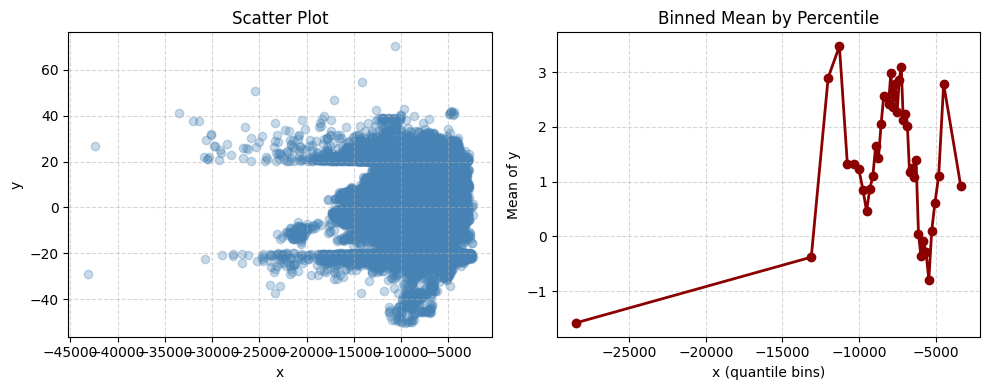

Plotting stats_ 2
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_2_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_2_0_vs_revenue.png'
💾 Saved to backup location: stats_2_vs_revenue.png


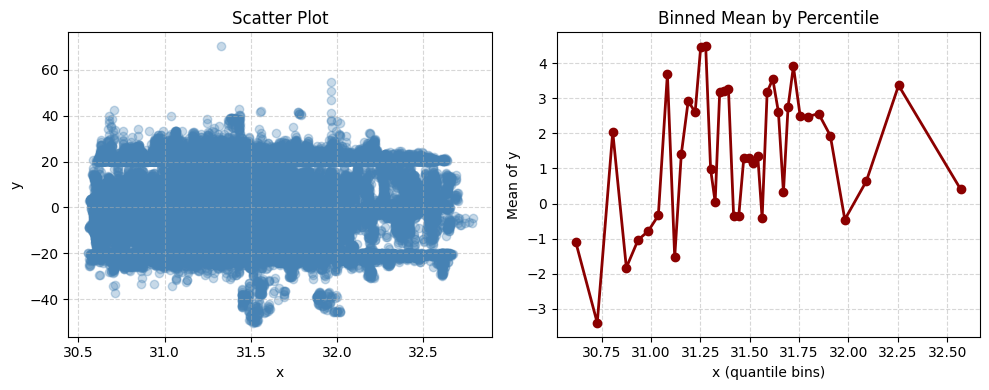

Plotting stats_ 3
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_3_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_3_0_vs_revenue.png'
💾 Saved to backup location: stats_3_vs_revenue.png


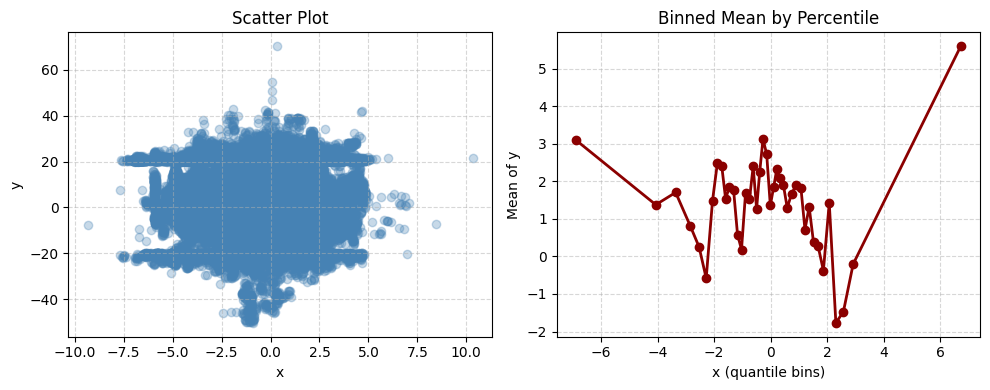

Plotting stats_ 4
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_4_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_4_0_vs_revenue.png'
💾 Saved to backup location: stats_4_vs_revenue.png


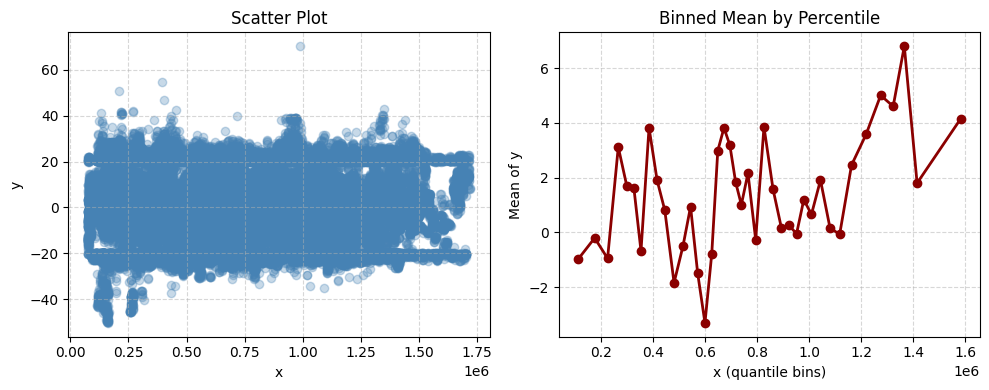

Plotting stats_ 5
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_5_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_5_0_vs_revenue.png'
💾 Saved to backup location: stats_5_vs_revenue.png


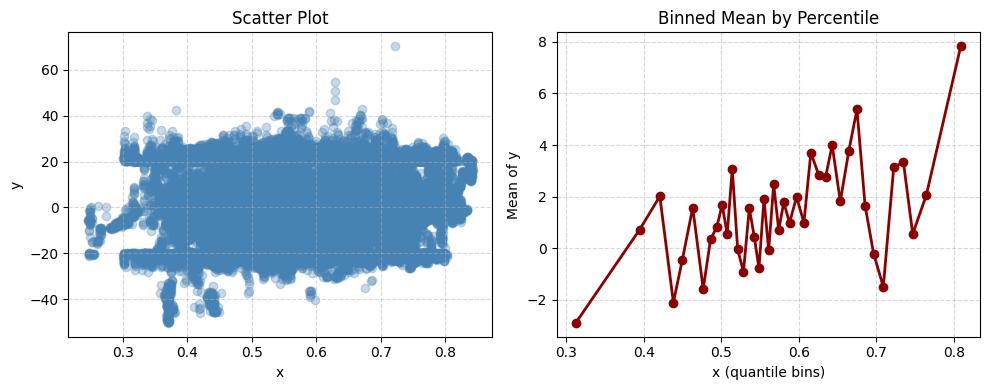

Plotting stats_ 6
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_6_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_6_0_vs_revenue.png'
💾 Saved to backup location: stats_6_vs_revenue.png


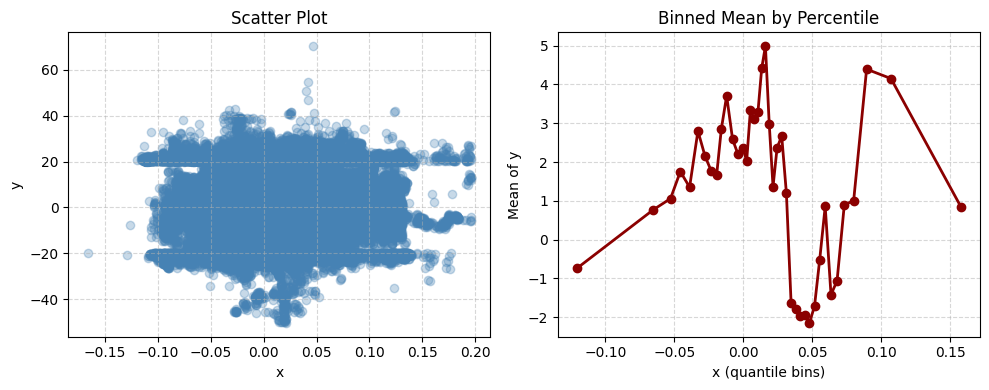

Plotting stats_ 7
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_7_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_7_0_vs_revenue.png'
💾 Saved to backup location: stats_7_vs_revenue.png


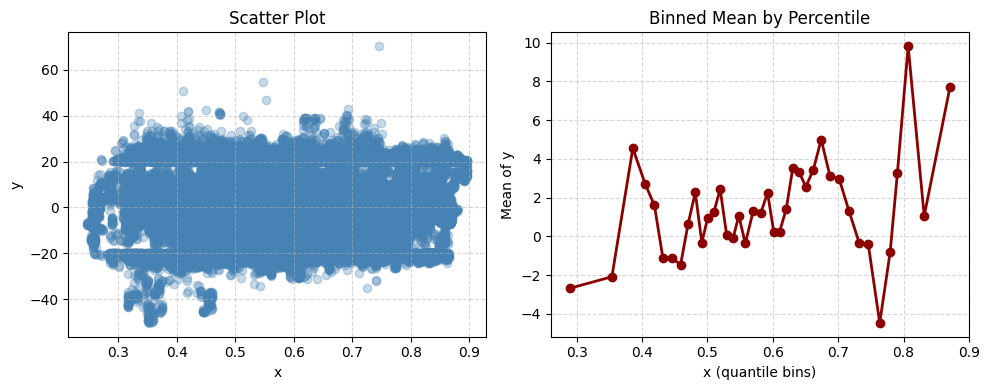

Plotting stats_ 8
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_8_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_8_0_vs_revenue.png'
💾 Saved to backup location: stats_8_vs_revenue.png


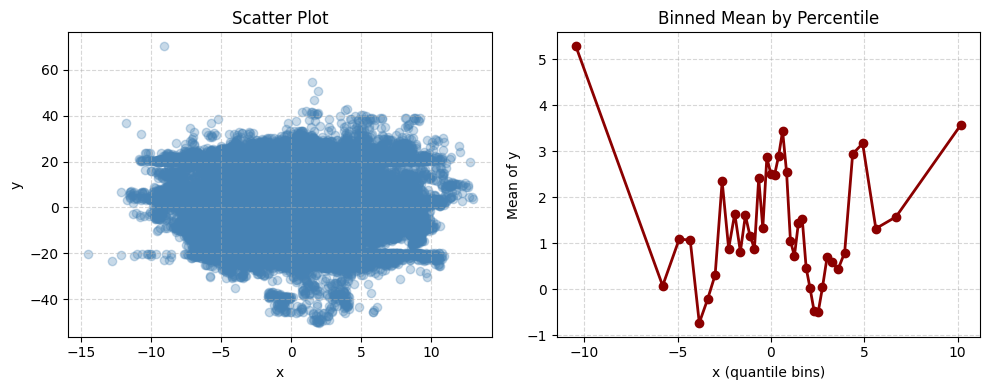

Plotting stats_ 9
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_9_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_9_0_vs_revenue.png'
💾 Saved to backup location: stats_9_vs_revenue.png


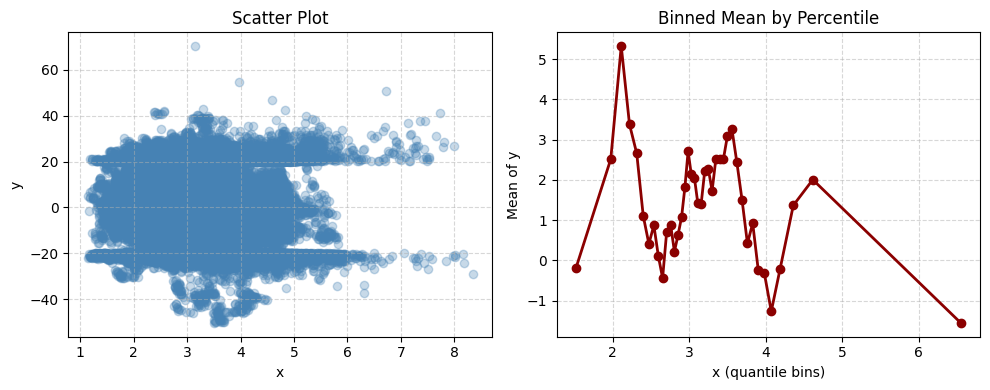

Plotting stats_ 10
❌ Error saving /Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_10_0_vs_revenue.png: [Errno 2] No such file or directory: '/Users/lizeyu/Desktop/Quant-on-Crypto/tp/stats_10_0_vs_revenue.png'
💾 Saved to backup location: stats_10_vs_revenue.png


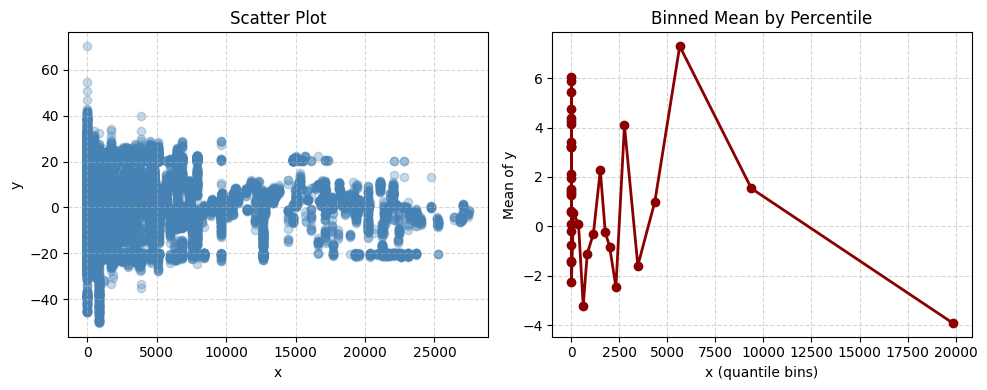

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
i = 0
for stats in [stats_1, stats_2, stats_3, stats_4, stats_5, stats_6, stats_7, stats_8, stats_9, stats_10]:
    i+=1
    print("Plotting stats_", i)



    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    x = np.array(stats)
    y = np.array(revenues)

    # === 按百分比分箱 ===
    n_bins = 40
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(x, quantiles)  # 按x的分位数分箱

    # 为避免重复的边界（在x有重复值时）
    bins = np.unique(bins)

    bin_labels = pd.cut(x, bins=bins, include_lowest=True)
    bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
    bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

    # === 两个子图（不共享 y） ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

    # 左边：散点图
    ax1.scatter(x, y, alpha=0.3, color='steelblue')
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_title("Scatter Plot")
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 右边：分箱均值图
    ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
    ax2.set_xlabel("x (quantile bins)")
    ax2.set_ylabel("Mean of y")
    ax2.set_title("Binned Mean by Percentile")
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    # 修复保存路径
    plot_dir = "/Users/lizeyu/Desktop/Quant-on-Crypto/tp"

    filename = f"stats_{i}_{start_t}_vs_revenue.png"
    filepath = os.path.join(plot_dir, filename)
    
    try:
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {filepath}")
    except Exception as e:
        print(f"❌ Error saving {filepath}: {e}")
        # 备用方案：保存到当前目录
        backup_path = f"stats_{i}_vs_revenue.png"
        plt.savefig(backup_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved to backup location: {backup_path}")
    
    plt.show()
    plt.close()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# i = 0
# for stats in [stats_1, stats_2, stats_3, stats_4, stats_5, stats_6, stats_7, stats_8, stats_9]:
#     i+=1
#     print("Plotting stats_", i)



#     import numpy as np
#     import matplotlib.pyplot as plt
#     import pandas as pd

#     x = np.array(stats)
#     y = np.array(revenues)

#     # === 按百分比分箱 ===
#     n_bins = 40
#     quantiles = np.linspace(0, 1, n_bins + 1)
#     bins = np.quantile(x, quantiles)  # 按x的分位数分箱

#     # 为避免重复的边界（在x有重复值时）
#     bins = np.unique(bins)

#     bin_labels = pd.cut(x, bins=bins, include_lowest=True)
#     bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
#     bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

#     # === 两个子图（不共享 y） ===
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

#     # 左边：散点图
#     ax1.scatter(x, y, alpha=0.3, color='steelblue')
#     ax1.set_xlabel("x")
#     ax1.set_ylabel("y")
#     ax1.set_title("Scatter Plot")
#     ax1.grid(True, linestyle='--', alpha=0.5)

#     # 右边：分箱均值图
#     ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
#     ax2.set_xlabel("x (quantile bins)")
#     ax2.set_ylabel("Mean of y")
#     ax2.set_title("Binned Mean by Percentile")
#     ax2.grid(True, linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()
#     plt.close()



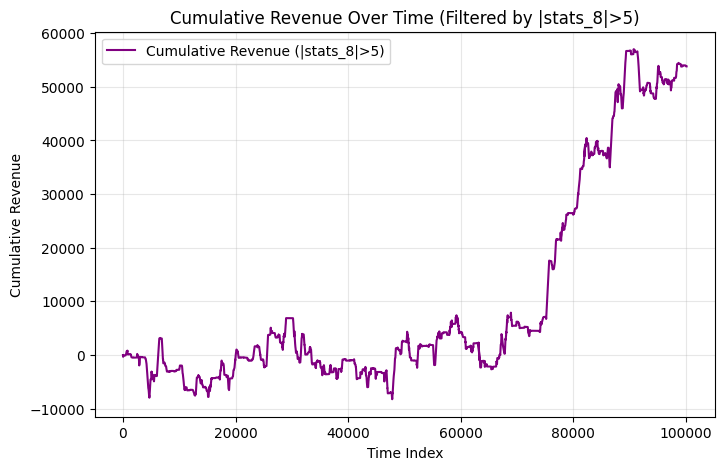

In [ ]:
all_df= pd.DataFrame({
    'stats_8': stats_8,
    'revenues': revenues
})
temp_df= all_df[abs(all_df['stats_8'])>3]
average_revenue = temp_df['revenues'].mean()
cumulative_revenue = temp_df['revenues'].cumsum()
plt.figure(figsize=(8, 5))
plt.plot(cumulative_revenue, label='Cumulative Revenue (|stats_8|>5)', color='purple', linewidth=1.5)
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.title("Cumulative Revenue Over Time (Filtered by |stats_8|>5)")
plt.grid(alpha=0.3)
plt.legend()


In [ ]:
average_revenue

np.float64(1.4315826923530954)

In [ ]:
# revenues

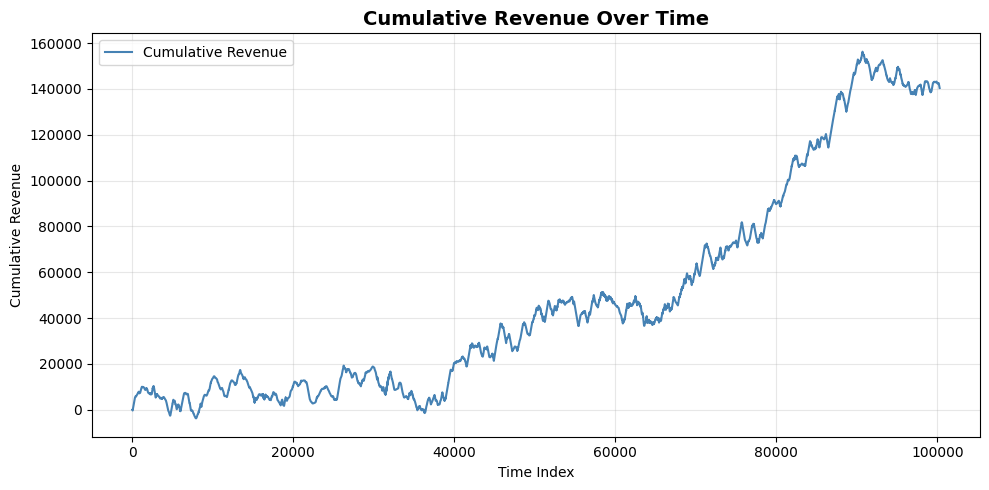

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 revenue_series 是 pandas Series 或 numpy array
# 示例：
revenue_series = pd.Series(revenues)

# 1️⃣ 累积收益
cumulative_revenue = np.cumsum(revenue_series)

# 2️⃣ 绘图
plt.figure(figsize=(10, 5))
plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_revenue.png", dpi=300)


In [ ]:
revenue_series.describe()

count    100293.000000
mean          1.399963
std          15.706535
min         -50.335820
25%         -10.917386
50%           1.359230
75%          20.070787
max          70.281325
dtype: float64

In [ ]:
all_df= pd.DataFrame({
    'stats_1': stats_1,
    'stats_2': stats_2,
    'stats_3': stats_3,
    'stats_4': stats_4,
    'stats_5': stats_5,
    'stats_6': stats_6,
    'stats_7': stats_7,
    'stats_8': stats_8,
    'stats_9': stats_9,
    'stats_10': stats_10,
    'revenues': revenues
})

In [ ]:
# 将 coin_revenues 字典转换为 DataFrame 并保存为 CSV
import pandas as pd
import numpy as np

# 方法1: 直接转换为宽格式 DataFrame（每列是一个币种）
coin_df = pd.DataFrame(coin_revenues)

# 处理长度不一致的问题（如果存在）
print(f"Coin revenues DataFrame shape: {coin_df.shape}")
print("Coin revenues DataFrame preview:")
print(coin_df.head())

# 保存为 CSV
coin_df.to_csv("coin_revenues.csv", index=True)
print("✅ Saved coin_revenues.csv")

Coin revenues DataFrame shape: (100293, 34)
Coin revenues DataFrame preview:
        IMXUSDT  SOLUSDT       LTCUSDT       SUIUSDT      NEARUSDT  ATOMUSDT  \
0 -6.608441e-17     -0.0  8.925927e-16 -0.000000e+00 -1.969515e-16      -0.0   
1 -0.000000e+00     -0.0 -0.000000e+00 -0.000000e+00 -6.248056e-16      -0.0   
2 -0.000000e+00     -0.0  1.162030e-15 -0.000000e+00  3.183020e-16      -0.0   
3 -0.000000e+00     -0.0  1.217851e-15 -0.000000e+00 -0.000000e+00      -0.0   
4  3.476225e-16     -0.0 -0.000000e+00 -4.516308e-16 -9.156688e-16      -0.0   

        APTUSDT      GALAUSDT  ARBUSDT    TRXUSDT  ...  OPUSDT      AVAXUSDT  \
0 -0.000000e+00 -0.000000e+00     -0.0 -16.753635  ...    -0.0 -0.000000e+00   
1 -0.000000e+00  2.558558e-16     -0.0 -16.524829  ...    -0.0 -0.000000e+00   
2 -0.000000e+00 -0.000000e+00     -0.0 -17.335210  ...    -0.0  8.563143e-16   
3  1.178004e-15 -0.000000e+00     -0.0 -17.581373  ...    -0.0 -2.228559e-16   
4 -2.738630e-16 -0.000000e+00     -0.0 -18

In [ ]:


all_df.to_csv("all_stats_vs_revenue.csv", index=False)